In [126]:
import pandas as pd
import numpy as np

In [127]:
df = pd.read_csv("10 pipe dataset (1).csv")

In [128]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [129]:
df.shape

(12316, 32)

<Axes: xlabel='Accident_severity'>

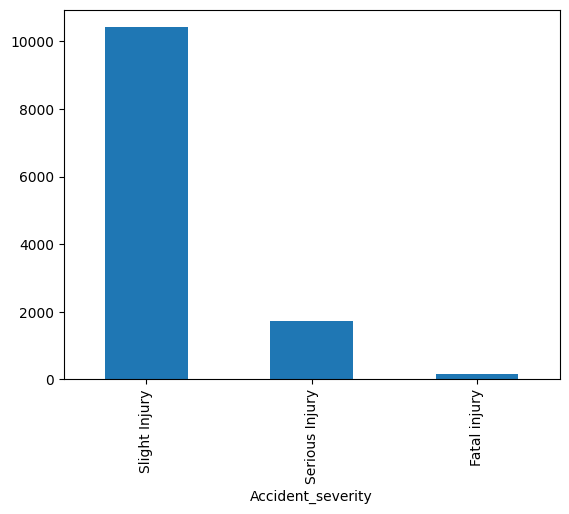

In [130]:
df['Accident_severity'].value_counts().plot(kind = 'bar')

<Axes: xlabel='Educational_level'>

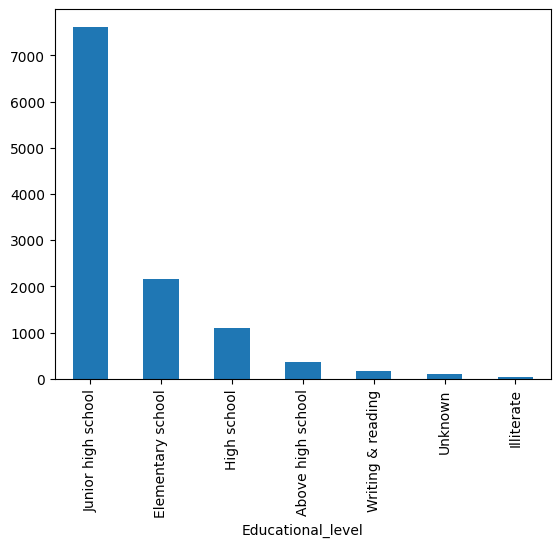

In [131]:
df['Educational_level'].value_counts().plot(kind = 'bar')

In [132]:
df['Time']

0        17:02:00
1        17:02:00
2        17:02:00
3         1:06:00
4         1:06:00
           ...   
12311    16:15:00
12312    18:00:00
12313    13:55:00
12314    13:55:00
12315    13:55:00
Name: Time, Length: 12316, dtype: object

In [133]:
df['Time'] = pd.to_datetime(df['Time'])

C:\Users\muska\AppData\Local\Temp\ipykernel_12200\2145562215.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


In [134]:
df['Time']

0       2025-07-16 17:02:00
1       2025-07-16 17:02:00
2       2025-07-16 17:02:00
3       2025-07-16 01:06:00
4       2025-07-16 01:06:00
                ...        
12311   2025-07-16 16:15:00
12312   2025-07-16 18:00:00
12313   2025-07-16 13:55:00
12314   2025-07-16 13:55:00
12315   2025-07-16 13:55:00
Name: Time, Length: 12316, dtype: datetime64[ns]

In [135]:
df[' Hour_of_day'] = df['Time'].dt.hour

In [136]:
df[' Hour_of_day']

0        17
1        17
2        17
3         1
4         1
         ..
12311    16
12312    18
12313    13
12314    13
12315    13
Name:  Hour_of_day, Length: 12316, dtype: int32

In [137]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour_of_day
0,2025-07-16 17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury,17
1,2025-07-16 17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury,17
2,2025-07-16 17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,2025-07-16 01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,2025-07-16 01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury,1


In [138]:
new_df = df.copy()
new_df.drop('Time', axis = 1, inplace = True)

In [139]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
new_df['Accident_severity'] = le.fit_transform(new_df['Accident_severity'])

In [140]:
new_df['Accident_severity'].value_counts()

Accident_severity
2    10415
1     1743
0      158
Name: count, dtype: int64

In [141]:
from imblearn.over_sampling import RandomOverSampler
X = new_df.drop('Accident_severity', axis = 1)
y = new_df['Accident_severity']
ros = RandomOverSampler(random_state = 42)
X_r , y_r = ros.fit_resample(X, y)

In [142]:
y_r.shape

(31245,)

In [143]:
y_r.value_counts()

Accident_severity
2    10415
1    10415
0    10415
Name: count, dtype: int64

In [144]:
X_r.shape

(31245, 31)

In [145]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_r, y_r, test_size=0.2, random_state=42)

In [146]:
X_train.shape

(24996, 31)

In [147]:
X_train.isnull().sum()

Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level              1755
Vehicle_driver_relation        1312
Driving_experience             1900
Type_of_vehicle                1872
Owner_of_vehicle                949
Service_year_of_vehicle        7443
Defect_of_vehicle              8843
Area_accident_occured           497
Lanes_or_Medians                720
Road_allignment                 299
Types_of_Junction              2198
Road_surface_type               296
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               363
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                800
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality              6598
Fitness_of_casuality        

In [148]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24996 entries, 25835 to 23654
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Day_of_week                  24996 non-null  object
 1   Age_band_of_driver           24996 non-null  object
 2   Sex_of_driver                24996 non-null  object
 3   Educational_level            23241 non-null  object
 4   Vehicle_driver_relation      23684 non-null  object
 5   Driving_experience           23096 non-null  object
 6   Type_of_vehicle              23124 non-null  object
 7   Owner_of_vehicle             24047 non-null  object
 8   Service_year_of_vehicle      17553 non-null  object
 9   Defect_of_vehicle            16153 non-null  object
 10  Area_accident_occured        24499 non-null  object
 11  Lanes_or_Medians             24276 non-null  object
 12  Road_allignment              24697 non-null  object
 13  Types_of_Junction            227

In [182]:
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
# unfill_cols = ['Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Type_of_collision', 'Vehicle_movement', 'Work_of_casuality', 'Fitness_of_casuality' ]
# unfill_cols1 = [ 'Service_year_of_vehicle', 'Defect_of_vehicle' ]
# tf1 = ColumnTransformer(
#     transformers =[
#     ('most_f', SimpleImputer(strategy='most_frequent'), unfill_cols),
#     ('const', SimpleImputer(strategy='constant', fill_value = 'Unknown'), unfill_cols1),
    
#     ],
#     remainder = 'passthrough'
# )
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Define the strategies for each column
strategies = {
    3: 'most_frequent',   # Educational_level
    4: 'most_frequent',   # Vehicle_driver_relation
    5: 'most_frequent',   # Driving_experience
    6: 'most_frequent',   # Type_of_vehicle
    8: 'constant',        # Service_year_of_vehicle
    9: 'constant',        # Defect_of_vehicle
    10: 'most_frequent',  # Area_accident_occured
    11: 'most_frequent',  # Lanes_or_Medians
    12: 'most_frequent',  # Road_allignment
    13: 'most_frequent',  # Types_of_Junction
    14: 'most_frequent',  # Road_surface_type
    18: 'most_frequent',  # Type_of_collision
    21: 'most_frequent',  # Vehicle_movement
    26: 'most_frequent',  # Work_of_casuality
    27: 'most_frequent'   # Fitness_of_casuality
}

# Create a ColumnTransformer for data preprocessing
tf1 = ColumnTransformer([
    ('impute_educational_level', SimpleImputer(strategy=strategies[3]), [3]),
    ('impute_Vehicle_driver_relation', SimpleImputer(strategy=strategies[4]), [4]),
    ('impute_Driving_experience', SimpleImputer(strategy=strategies[5]), [5]),
    ('impute_Type_of_vehicle', SimpleImputer(strategy=strategies[6]), [6]),
    ('impute_Service_year_of_vehicle', SimpleImputer(strategy=strategies[8], fill_value='Unknown'), [8]),
    ('impute_Defect_of_vehicle', SimpleImputer(strategy=strategies[9], fill_value='Unknown'), [9]),
    ('impute_Area_accident_occured', SimpleImputer(strategy=strategies[10]), [10]),
    ('impute_Lanes_or_Medians', SimpleImputer(strategy=strategies[11]), [11]),
    ('impute_Road_allignment', SimpleImputer(strategy=strategies[12]), [12]),
    ('impute_Types_of_Junction', SimpleImputer(strategy=strategies[13]), [13]),
    ('impute_Road_surface_type', SimpleImputer(strategy=strategies[14]), [14]),
    ('impute_Type_of_collision', SimpleImputer(strategy=strategies[18]), [18]),
    ('impute_Vehicle_movement', SimpleImputer(strategy=strategies[21]), [21]),
    ('impute_Work_of_casuality', SimpleImputer(strategy=strategies[26]), [26]),
    ('impute_Fitness_of_casuality', SimpleImputer(strategy=strategies[27]), [27])
], remainder='passthrough')

In [183]:
tf1

ColumnTransformer(remainder='passthrough',
                  transformers=[('impute_educational_level',
                                 SimpleImputer(strategy='most_frequent'), [3]),
                                ('impute_Vehicle_driver_relation',
                                 SimpleImputer(strategy='most_frequent'), [4]),
                                ('impute_Driving_experience',
                                 SimpleImputer(strategy='most_frequent'), [5]),
                                ('impute_Type_of_vehicle',
                                 SimpleImputer(strategy='most_frequent'), [6...
                                ('impute_Road_surface_type',
                                 SimpleImputer(strategy='most_frequent'),
                                 [14]),
                                ('impute_Type_of_collision',
                                 SimpleImputer(strategy='most_frequent'),
                                 [18]),
                                ('impute_Vehicle_movement',
                                 SimpleImputer(strategy='most_frequent'),
                                 [21]),
                                ('impute_Work_of_casuality',
                                 SimpleImputer(strategy='most_frequent'),
                                 [26]),
                                ('impute_Fitness_of_casuality',
                                 SimpleImputer(strategy='most_frequent'),
                                 [27])])

In [184]:
# X_train_t = tf1.fit_transform(X_train)

In [185]:
# X_train_t = pd.DataFrame(data = X_train_t, columns = tf1.get_feature_names_out())

In [186]:
# X_train_t.info()

In [187]:
# X_train[' Hour_of_day'].value_counts()

In [188]:
# from sklearn.preprocessing import OneHotEncoder
# cat_cols = [col for col in X_train.columns if X_train[col].nunique() < 25]  # e.g., <20 unique values = likely categorical
# num_cols = [col for col in X_train.columns if col not in cat_cols]
# for col in num_cols:
#     X_train[col] = pd.to_numeric(X_train[col], errors='coerce') 
# tf2 = ColumnTransformer(
#     transformers=[
#         ('one', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
#     ],
#     remainder='passthrough'  # keep numeric columns as-is
# )



In [189]:
from sklearn.preprocessing import OneHotEncoder

# Define the object columns indices
object_columns_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,19,20,21,22,23,24,25,26,27,28,29,30]

# Create a ColumnTransformer for one-hot encoding only object columns
tf2 = ColumnTransformer([
    (f'ohe_{col}', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [col])
    for col in object_columns_indices
], remainder='passthrough')

# Apply the transformation
X_train_encoded = tf2.fit_transform(X_train)
X_train_encoded.shape

(24996, 258)

In [190]:
# X_train_tf = tf2.fit_transform(X_train)

In [191]:
# X_train_tf = pd.DataFrame(data = X_train_tf, columns = tf2.get_feature_names_out())

In [192]:
# X_train_tf.head()

Feature selection

In [193]:
from sklearn.feature_selection import SelectKBest, chi2
tf3 = SelectKBest(chi2, k= 50) 


RandomForestClassifier

In [194]:
from sklearn.ensemble import RandomForestClassifier
tf4 = RandomForestClassifier()

PipeLine

In [195]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('trf1', tf1),
    ('trf2', tf2),
    ('trf3', tf3),
    ('trf4', tf4),
    
])

In [196]:
pipe

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_educational_level',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [3]),
                                                 ('impute_Vehicle_driver_relation',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [4]),
                                                 ('impute_Driving_experience',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [5]),
                                                 ('impute_Type_of_vehicle',
                                                  SimpleImputer(stra...
                                                                sparse_output=False),
                                                  [26]),
                                                 ('ohe_27',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [27]),
                                                 ('ohe_28',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [28]),
                                                 ('ohe_29',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [29]), ...])),
                ('trf3',
                 SelectKBest(k=50,
                             score_func=<function chi2 at 0x00000288F6F9EC00>)),
                ('trf4', RandomForestClassifier())])

In [197]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_educational_level',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [3]),
                                                 ('impute_Vehicle_driver_relation',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [4]),
                                                 ('impute_Driving_experience',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [5]),
                                                 ('impute_Type_of_vehicle',
                                                  SimpleImputer(stra...
                                                                sparse_output=False),
                                                  [26]),
                                                 ('ohe_27',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [27]),
                                                 ('ohe_28',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [28]),
                                                 ('ohe_29',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [29]), ...])),
                ('trf3',
                 SelectKBest(k=50,
                             score_func=<function chi2 at 0x00000288F6F9EC00>)),
                ('trf4', RandomForestClassifier())])

In [198]:
pipe.classes_

array([0, 1, 2])

In [199]:
pipe.named_steps

{'trf1': ColumnTransformer(remainder='passthrough',
                   transformers=[('impute_educational_level',
                                  SimpleImputer(strategy='most_frequent'), [3]),
                                 ('impute_Vehicle_driver_relation',
                                  SimpleImputer(strategy='most_frequent'), [4]),
                                 ('impute_Driving_experience',
                                  SimpleImputer(strategy='most_frequent'), [5]),
                                 ('impute_Type_of_vehicle',
                                  SimpleImputer(strategy='most_frequent'), [6...
                                 ('impute_Road_surface_type',
                                  SimpleImputer(strategy='most_frequent'),
                                  [14]),
                                 ('impute_Type_of_collision',
                                  SimpleImputer(strategy='most_frequent'),
                                  [18]),
               

In [200]:
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, classification_report
y_pred = pipe.predict(X_test)
y_pred

array([1, 2, 2, ..., 0, 1, 2], shape=(6249,))

In [201]:
accuracy_score(y_test, y_pred)

0.9228676588254121

In [202]:
confusion_matrix(y_test, y_pred) 

array([[2085,    0,    0],
       [  22, 1995,   83],
       [  25,  352, 1687]])

In [203]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2085
           1       0.85      0.95      0.90      2100
           2       0.95      0.82      0.88      2064

    accuracy                           0.92      6249
   macro avg       0.93      0.92      0.92      6249
weighted avg       0.93      0.92      0.92      6249



In [204]:
import pickle
pickle.dump(pipe, open("pipe.pkl", 'wb'))

In [205]:
import numpy as np

# record from X_test 10 row
print("Prediction :",pipe.predict(np.array([['Thursday', '31-50', 'Male', 'Junior high school', 'Owner', 'Unknown', 'Long lorry', 'Owner', 
                       'Unknown', 'Unknown', 'Other', 'Two-way (divided with solid lines road marking)',
                       'Tangent road with flat terrain','Unknown', 'Unknown', 'Dry', 'Daylight', 'Normal', 
                       'Collision with animals', 2, 1, 'Going straight', 'Driver or rider','Male', '18-30', 3, 'Driver',
                       'Normal', 'Not a Pedestrian', 'Changing lane to the left', 12,]],dtype=object).reshape(1,-1)))
print("Actual :",y_test.iloc[10])

Prediction : [1]
Actual : 1


C:\Users\muska\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\muska\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\muska\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\muska\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\muska\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserW

### prediction system

In [206]:
X_train.columns

Index(['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', ' Hour_of_day'],
      dtype='object')

In [208]:
def pred(Day_of_week, Age_band_of_driver, Sex_of_driver, Educational_level, Vehicle_driver_relation,
         Driving_experience, Type_of_vehicle, Owner_of_vehicle, Service_year_of_vehicle,
         Defect_of_vehicle, Area_accident_occured, Lanes_or_Medians, Road_allignment,
         Types_of_Junction, Road_surface_type, Road_surface_conditions, Light_conditions,
         Weather_conditions, Type_of_collision, Number_of_vehicles_involved,
         Number_of_casualties, Vehicle_movement, Casualty_class, Sex_of_casualty,
         Age_band_of_casualty, Casualty_severity, Work_of_casuality, Fitness_of_casuality,
         Pedestrian_movement, Cause_of_accident, Hour_of_Day):
    
    # Your prediction code here
    features = np.array([[Day_of_week, Age_band_of_driver, Sex_of_driver, Educational_level, Vehicle_driver_relation,
         Driving_experience, Type_of_vehicle, Owner_of_vehicle, Service_year_of_vehicle,
         Defect_of_vehicle, Area_accident_occured, Lanes_or_Medians, Road_allignment,
         Types_of_Junction, Road_surface_type, Road_surface_conditions, Light_conditions,
         Weather_conditions, Type_of_collision, Number_of_vehicles_involved,
         Number_of_casualties, Vehicle_movement, Casualty_class, Sex_of_casualty,
         Age_band_of_casualty, Casualty_severity, Work_of_casuality, Fitness_of_casuality,
         Pedestrian_movement, Cause_of_accident, Hour_of_Day]])
    
    results = pipe.predict(features)
    return results
    

In [209]:
predicted_class = pred(Day_of_week="Thursday", 
                                Age_band_of_driver='31-50',
                                Sex_of_driver='Male',
                                Educational_level='Junior high school',
                                Vehicle_driver_relation='Owner',
                                Driving_experience=None,
                                Type_of_vehicle='Long lorry',
                                Owner_of_vehicle='Owner',
                                Service_year_of_vehicle='Unknown',
                                Defect_of_vehicle=None,
                                Area_accident_occured='Other',
                                Lanes_or_Medians='Two-way (divided with solid lines road marking)',
                                Road_allignment='Tangent road with flat terrain',
                                Types_of_Junction=None,
                                Road_surface_type=None,
                                Road_surface_conditions='Dry',
                                Light_conditions='Daylight',
                                Weather_conditions='Normal',
                                Type_of_collision='Collision with animals',
                                Number_of_vehicles_involved=2,
                                Number_of_casualties=1,
                                Vehicle_movement='Going straight',
                                Casualty_class='Driver or rider',
                                Sex_of_casualty='Male',
                                Age_band_of_casualty='18-30',
                                Casualty_severity=3,
                                Work_of_casuality='Driver',
                                Fitness_of_casuality='Normal',
                                Pedestrian_movement='Not a Pedestrian',
                                Cause_of_accident='Changing lane to the left',
                                Hour_of_Day=12)

if predicted_class[0] == 2:
    print("Slight Injury.....")
elif predicted_class[0] == 1:
    print("Serious Injury")
else:
    print("Fatal Injury")         

    

Serious Injury


C:\Users\muska\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\muska\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\muska\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\muska\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\muska\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserW